### Compare MRB and MirrorQA Experiments

This section configures and runs three benchmarking experiments using the same simulated quantum backend: **MirrorRB**, **MirrorQA**, and **MirrorQA with start/end Clifford layers enabled**. Using identical runtime parameters allows for a fair comparison of the different benchmarking methods. The experiment settings, such as the number of shots, circuit lengths, number of samples, and qubits, can be adjusted to explore different benchmarking configurations. Each experiment is executed, timed, and its corresponding job ID is displayed for reference.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit_device_benchmarking.bench_code.mrb import MirrorRB, QuantumAwesomeness
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import pickle
import time

# Define parameters for the simulated backend
num_qubits = 5
basis_gates = ["id", "h", "x", "y", "z","rz", "cx"]
p1 = 0.001  # 1-qubit gate error probability
p2 = 0.01  # 2-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle

# Create a coupling map as a list of tuples
#coupling_list = [(i, j) for i in range(num_qubits) for j in range(num_qubits) if i != j]

fez_edges = [
    (0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4),  
    (4, 3)
]


#fez_edges = [(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8), (9, 10), (10, 9), (10, 11), (11, 10), (11, 12), (11, 18), (12, 11), (12, 13), (13, 12), (13, 14), (14, 13), (14, 15), (15, 14), (15, 19), (16, 3), (16, 23), (17, 7), (17, 27), (18, 11), (18, 31), (19, 15), (19, 35), (20, 21), (21, 20), (21, 22), (21, 36), (22, 21), (22, 23), (23, 16), (23, 22), (23, 24), (24, 23), (24, 25), (25, 24), (25, 26), (25, 37), (26, 25), (26, 27), (27, 17), (27, 26), (27, 28), (28, 27), (28, 29), (29, 28), (29, 30), (29, 38), (30, 29), (30, 31), (31, 18), (31, 30), (31, 32), (32, 31), (32, 33), (33, 32), (33, 34), (33, 39), (34, 33), (34, 35), (35, 19), (35, 34), (36, 21), (36, 41), (37, 25), (37, 45), (38, 29), (38, 49), (39, 33), (40, 41), (41, 36), (41, 40), (41, 42), (42, 41), (42, 43), (43, 42), (43, 44), (44, 43), (44, 45), (45, 37), (45, 44), (45, 46), (46, 45), (46, 47), (47, 46), (47, 48), (48, 47), (48, 49), (49, 38), (49, 48)


# Create the coupling map (already bidirectional above)
coupling_map = CouplingMap(couplinglist=fez_edges)

# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])),
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),
        "x": Operator(np.array([[0, 1], [1, 0]])),
        "y": Operator(np.array([[0, -1j], [1j, 0]])),
        "z": Operator(np.array([[1, 0], [0, -1]])),
        "rz": Operator(np.array([[np.exp(-1j * rz_angle / 2), 0], [0, np.exp(1j * rz_angle / 2)]])),
        "s": Operator(np.array([[1, 0], [0, 1j]])),
        "cx": Operator(np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]]))
    }
)

# Create a noise model
noise_model = NoiseModel()
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "s", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=123
)

shots = 100
lengths = [2, 4, 10, 20, 50]
num_samples = 5

# ---------------- MirrorRB ----------------
exp = MirrorRB(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    seed=123
)

exp.set_run_options(shots=shots)

print("Starting MirrorRB simulation...")
start_time = time.time()
rb_data = exp.run()
end_time = time.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds")
print("Job IDs:", rb_data.job_ids)


# ---------------- MirrorQA ----------------
exp1 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    seed=123
)

exp1.set_run_options(shots=shots)

print("Starting MirrorQA simulation...")
start_time = time.time()
qa_data = exp1.run()
end_time = time.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds")
print("Job IDs:", qa_data.job_ids)


# -------- MirrorQA with start/end Cliffords --------
exp2 = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    seed=123
)

# Enable start/end Clifford layers
exp2.set_experiment_options(start_end_clifford=True)

exp2.set_run_options(shots=shots)

print("Starting MirrorQA with start/end Clifford simulation...")
start_time = time.time()
qa1_data = exp2.run()
end_time = time.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds")
print("Job IDs:", qa1_data.job_ids)





Starting MirrorRB simulation...
Simulation completed in 2.45 seconds
Job IDs: ['de46248c-215a-42fe-bc52-cab44248a510']
Starting MirrorQA simulation...
Simulation completed in 1.00 seconds
Job IDs: ['020da2d7-835e-453c-9aa1-358343811605']
Starting MirrorQA with start/end Clifford simulation...
Simulation completed in 3.20 seconds
Job IDs: ['d9b62d34-b945-4c11-ba60-42da3b340459']


In [2]:
print('Pairs:', exp._pairs[0])
exp._static_trans_circuits[0].draw(fold=-1)

Pairs: [(0, 1), (3, 4)]


global phase: π/2
        ┌─────────┐   ┌───┐    ░            ┌───┐┌─────────┐┌───┐ ░             ░ ┌─────────┐   ┌───┐    ░                  ░                  ░ ┌─────────┐   ┌───┐                    ░  ░ ┌─┐            
   q_0: ┤ Rz(π/2) ├───┤ Y ├────░──────■─────┤ H ├┤ Rz(π/2) ├┤ H ├─░──────■──────░─┤ Rz(π/2) ├───┤ Y ├────░──────■───────────░──────■───────────░─┤ Rz(π/2) ├───┤ Y ├────────────────────░──░─┤M├────────────
        └──┬───┬──┘   └───┘    ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░    ┌─┴─┐    ░ └──┬───┬──┘   └───┘    ░    ┌─┴─┐         ░    ┌─┴─┐         ░ └──┬───┬──┘   └───┘                    ░  ░ └╥┘┌─┐         
   q_1: ───┤ H ├───────────────░────┤ X ├─────────────────────────░────┤ X ├────░────┤ H ├───────────────░────┤ X ├─────────░────┤ X ├─────────░────┤ H ├───────────────────────────────░──░──╫─┤M├─────────
           ├───┤   ┌─────────┐ ░ ┌──┴───┴──┐                      ░ ┌──┴───┴──┐ ░    ├───┤   ┌─────────┐ ░ ┌──┴───┴──┐┌───┐ ░ ┌──┴───┴──┐┌───┐ ░    ├───┤   ┌─────────┐┌───┐┌─────────┐ ░  ░  ║ └╥┘┌─┐      
   q_2: ───┤ H ├───┤ Rz(π/2) ├─░─┤ Rz(π/2) ├──────────────────────░─┤ Rz(π/2) ├─░────┤ H ├───┤ Rz(π/2) ├─░─┤ Rz(π/2) ├┤ Z ├─░─┤ Rz(π/2) ├┤ Z ├─░────┤ H ├───┤ Rz(π/2) ├┤ H ├┤ Rz(π/2) ├─░──░──╫──╫─┤M├──────
        ┌──┴───┴──┐└─────────┘ ░ └─────────┘┌───┐┌─────────┐┌───┐ ░ └─────────┘ ░ ┌──┴───┴──┐└─────────┘ ░ └─────────┘└───┘ ░ └─────────┘└───┘ ░ ┌──┴───┴──┐└──┬───┬──┘└───┘└─────────┘ ░  ░  ║  ║ └╥┘┌─┐   
   q_3: ┤ Rz(π/2) ├────────────░──────■─────┤ H ├┤ Rz(π/2) ├┤ H ├─░──────■──────░─┤ Rz(π/2) ├────────────░──────■───────────░──────■───────────░─┤ Rz(π/2) ├───┤ Z ├────────────────────░──░──╫──╫──╫─┤M├───
        ├─────────┤            ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░    ┌─┴─┐    ░ ├─────────┤            ░    ┌─┴─┐         ░    ┌─┴─┐         ░ ├─────────┤   ├───┤                    ░  ░  ║  ║  ║ └╥┘┌─┐
   q_4: ┤ Rz(π/2) ├────────────░────┤ X ├─────────────────────────░────┤ X ├────░─┤ Rz(π/2) ├────────────░────┤ X ├─────────░────┤ X ├─────────░─┤ Rz(π/2) ├───┤ Z ├────────────────────░──░──╫──╫──╫──╫─┤M├
        └─────────┘            ░    └───┘                         ░    └───┘    ░ └─────────┘            ░    └───┘         ░    └───┘         ░ └─────────┘   └───┘                    ░  ░  ║  ║  ║  ║ └╥┘
meas: 5/══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                                                                                                              0  1  2  3  4

The following cell is to check the circuits of the MQA analysis (with initial and final cliffords in the circuits) which prints same as MRB 

In [3]:
print('Pairs:', exp2._pairs[0])
exp2._static_trans_circuits[0].draw(fold=-1)

Pairs: [(0, 1), (3, 4)]


global phase: π/2
        ┌─────────┐   ┌───┐    ░            ┌───┐┌─────────┐┌───┐ ░             ░ ┌─────────┐   ┌───┐    ░                  ░                  ░ ┌─────────┐   ┌───┐                    ░  ░ ┌─┐            
   q_0: ┤ Rz(π/2) ├───┤ Y ├────░──────■─────┤ H ├┤ Rz(π/2) ├┤ H ├─░──────■──────░─┤ Rz(π/2) ├───┤ Y ├────░──────■───────────░──────■───────────░─┤ Rz(π/2) ├───┤ Y ├────────────────────░──░─┤M├────────────
        └──┬───┬──┘   └───┘    ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░    ┌─┴─┐    ░ └──┬───┬──┘   └───┘    ░    ┌─┴─┐         ░    ┌─┴─┐         ░ └──┬───┬──┘   └───┘                    ░  ░ └╥┘┌─┐         
   q_1: ───┤ H ├───────────────░────┤ X ├─────────────────────────░────┤ X ├────░────┤ H ├───────────────░────┤ X ├─────────░────┤ X ├─────────░────┤ H ├───────────────────────────────░──░──╫─┤M├─────────
           ├───┤   ┌─────────┐ ░ ┌──┴───┴──┐                      ░ ┌──┴───┴──┐ ░    ├───┤   ┌─────────┐ ░ ┌──┴───┴──┐┌───┐ ░ ┌──┴───┴──┐┌───┐ ░    ├───┤   ┌─────────┐┌───┐┌─────────┐ ░  ░  ║ └╥┘┌─┐      
   q_2: ───┤ H ├───┤ Rz(π/2) ├─░─┤ Rz(π/2) ├──────────────────────░─┤ Rz(π/2) ├─░────┤ H ├───┤ Rz(π/2) ├─░─┤ Rz(π/2) ├┤ Z ├─░─┤ Rz(π/2) ├┤ Z ├─░────┤ H ├───┤ Rz(π/2) ├┤ H ├┤ Rz(π/2) ├─░──░──╫──╫─┤M├──────
        ┌──┴───┴──┐└─────────┘ ░ └─────────┘┌───┐┌─────────┐┌───┐ ░ └─────────┘ ░ ┌──┴───┴──┐└─────────┘ ░ └─────────┘└───┘ ░ └─────────┘└───┘ ░ ┌──┴───┴──┐└──┬───┬──┘└───┘└─────────┘ ░  ░  ║  ║ └╥┘┌─┐   
   q_3: ┤ Rz(π/2) ├────────────░──────■─────┤ H ├┤ Rz(π/2) ├┤ H ├─░──────■──────░─┤ Rz(π/2) ├────────────░──────■───────────░──────■───────────░─┤ Rz(π/2) ├───┤ Z ├────────────────────░──░──╫──╫──╫─┤M├───
        ├─────────┤            ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░    ┌─┴─┐    ░ ├─────────┤            ░    ┌─┴─┐         ░    ┌─┴─┐         ░ ├─────────┤   ├───┤                    ░  ░  ║  ║  ║ └╥┘┌─┐
   q_4: ┤ Rz(π/2) ├────────────░────┤ X ├─────────────────────────░────┤ X ├────░─┤ Rz(π/2) ├────────────░────┤ X ├─────────░────┤ X ├─────────░─┤ Rz(π/2) ├───┤ Z ├────────────────────░──░──╫──╫──╫──╫─┤M├
        └─────────┘            ░    └───┘                         ░    └───┘    ░ └─────────┘            ░    └───┘         ░    └───┘         ░ └─────────┘   └───┘                    ░  ░  ║  ║  ║  ║ └╥┘
meas: 5/══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                                                                                                              0  1  2  3  4

The following cell is to check the circuits of the MQA analysis (without initial and final cliffords in the circuits)

In [4]:
print('Pairs:', exp1._pairs[0])
exp1._static_trans_circuits[0].draw(fold=-1)

Pairs: [(0, 1), (3, 4)]


global phase: π
        ┌───┐ ░            ┌───┐┌─────────┐┌───┐ ░ ┌───┐ ░                  ░ ┌───┐ ░  ░ ┌─┐            
   q_0: ┤ Y ├─░──────■─────┤ H ├┤ Rz(π/2) ├┤ H ├─░─┤ Y ├─░──────■───────────░─┤ Y ├─░──░─┤M├────────────
        └───┘ ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░ ├───┤ ░    ┌─┴─┐         ░ ├───┤ ░  ░ └╥┘┌─┐         
   q_1: ──────░────┤ X ├─────────────────────────░─┤ X ├─░────┤ X ├─────────░─┤ Z ├─░──░──╫─┤M├─────────
              ░ ┌──┴───┴──┐                      ░ └───┘ ░ ┌──┴───┴──┐┌───┐ ░ ├───┤ ░  ░  ║ └╥┘┌─┐      
   q_2: ──────░─┤ Rz(π/2) ├──────────────────────░───────░─┤ Rz(π/2) ├┤ Z ├─░─┤ X ├─░──░──╫──╫─┤M├──────
              ░ └─────────┘┌───┐┌─────────┐┌───┐ ░ ┌───┐ ░ └─────────┘└───┘ ░ ├───┤ ░  ░  ║  ║ └╥┘┌─┐   
   q_3: ──────░──────■─────┤ H ├┤ Rz(π/2) ├┤ H ├─░─┤ X ├─░──────■───────────░─┤ Z ├─░──░──╫──╫──╫─┤M├───
              ░    ┌─┴─┐   └───┘└─────────┘└───┘ ░ ├───┤ ░    ┌─┴─┐         ░ ├───┤ ░  ░  ║  ║  ║ └╥┘┌─┐
   q_4: ──────░────┤ X ├─────────────────────────░─┤ X ├─░────┤ X ├─────────░─┤ Y ├─░──░──╫──╫──╫──╫─┤M├
              ░    └───┘                         ░ └───┘ ░    └───┘         ░ └───┘ ░  ░  ║  ║  ║  ║ └╥┘
meas: 5/══════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                          0  1  2  3  4

The following cell prints information about the qa_data object. You can modify it to use either rb or qa1, depending on what you want to analyze. You can also verify that rb and qa1 have the same counts or results by printing their data objects.

In [5]:
# show the rb_data object itself
print(qa_data)

# get the raw payload
data_entries = qa_data.data()

# print the number of entries and the first five
print("total entries:", len(data_entries))
for i, entry in enumerate(data_entries[0:1]):          # top‑5
    print(f"\nentry {i}:")
    print(entry)

# if you want to pretty‑print json‑like structures, use pprint
from pprint import pprint
pprint(data_entries[0:1])



---------------------------------------------------
Experiment: MirrorQA
Experiment ID: 2c8c00be-5f9e-48e6-b8e5-a3917880350f
Status: ExperimentStatus.DONE
Backend: AerSimulator('aer_simulator_stabilizer'
             noise_model=<NoiseModel on ['rz', 'cx', 'h', 'x', 'z', 'y', 'id']>)
Data: 25
Analysis Results: 3
Figures: 1
Artifacts: 2
total entries: 25

entry 0:
{'job_id': '020da2d7-835e-453c-9aa1-358343811605', 'meas_level': 2, 'meas_return': 'single', 'counts': {'11110': 31, '11101': 24, '00110': 19, '00101': 23, '11001': 1, '10110': 1, '01101': 1}, 'memory': ['11110', '11110', '11110', '11110', '11101', '11110', '00110', '11110', '00101', '11101', '00110', '00101', '00110', '00101', '00101', '00101', '11110', '00110', '00101', '00101', '11101', '11110', '11110', '00110', '00110', '11110', '00110', '11110', '11101', '11110', '11110', '11001', '00110', '11110', '00101', '00110', '11101', '00110', '11110', '11110', '00110', '00101', '11101', '11101', '00101', '00101', '11110', '00101'

In [6]:
for name, ex, data in [("analysis", exp, rb_data), ("analysis1", exp1, qa_data), ("analysis2", exp2, qa1_data)]:
    ex.analysis.set_options(analyzed_quantity="Effective Polarization")
    globals()[name] = ex.analysis.run(data)


In [7]:
print(rb_data.status())
print(rb_data.figure_names)

print(qa_data.status())
print(qa_data.figure_names)


print(qa1_data.status())
print(qa1_data.figure_names)



ExperimentStatus.DONE
['MirrorRB_Q0_Q1_Q2_Q3_Q4_2fb5c667.svg']
ExperimentStatus.DONE
['MirrorQA_Q0_Q1_Q2_Q3_Q4_2c8c00be.svg']
ExperimentStatus.DONE
['MirrorQA_Q0_Q1_Q2_Q3_Q4_e67754d1.svg']


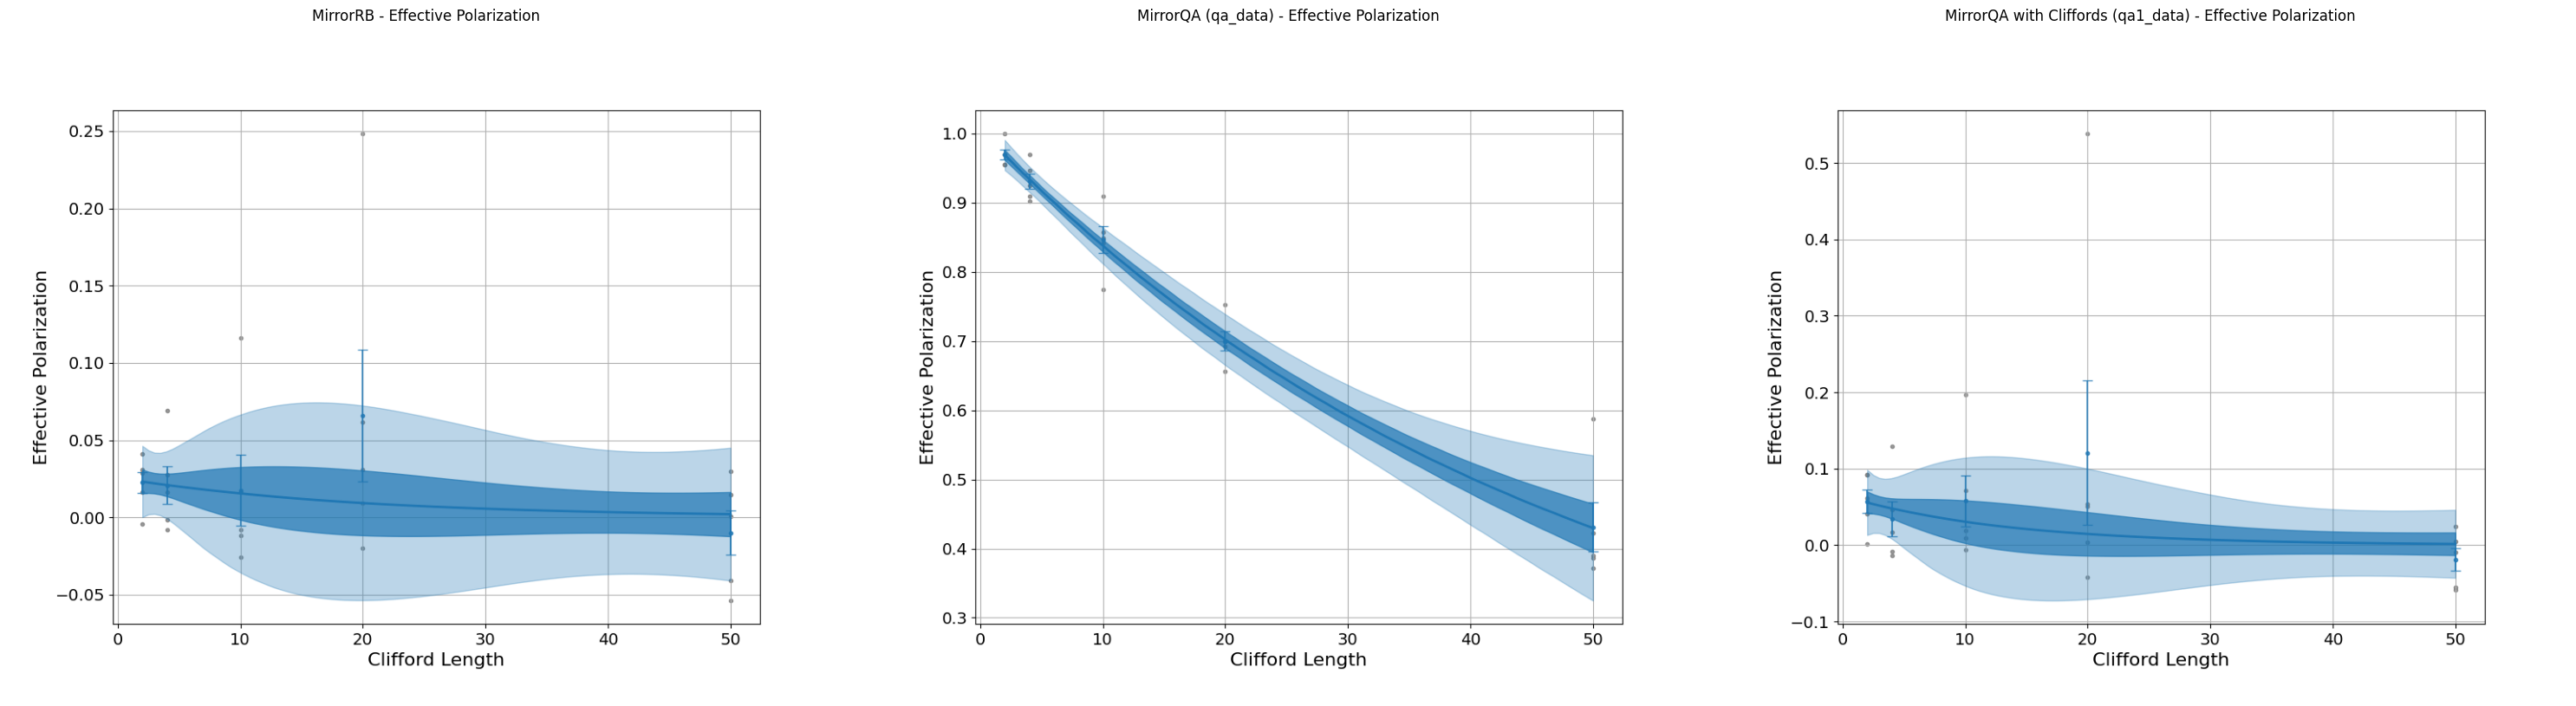

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
import numpy as np

def _to_mpl(fig):
    """Unwrap qiskit_experiments figure containers to a raw matplotlib Figure."""
    for attr in ("figure", "_figure"):
        if hasattr(fig, attr):
            val = getattr(fig, attr)
            return val() if callable(val) else val
    return fig

def _fig_to_rgba(mpl_fig, width_in=10, height_in=8):
    """Render a matplotlib figure at the specified size and return as RGBA array."""
    mpl_fig.set_size_inches(width_in, height_in)
    canvas = FigureCanvasAgg(mpl_fig)
    canvas.draw()
    return np.asarray(canvas.buffer_rgba())

panels = [
    (analysis.figure(0),  "MirrorRB - Effective Polarization"),
    (analysis1.figure(0), "MirrorQA (qa_data) - Effective Polarization"),
    (analysis2.figure(0), "MirrorQA with Cliffords (qa1_data) - Effective Polarization"),
]

arrays = [_fig_to_rgba(_to_mpl(f)) for f, _ in panels]
titles = [t for _, t in panels]

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
for ax, arr, title in zip(axes, arrays, titles):
    ax.imshow(arr)
    ax.axis("off")
    ax.set_title(title, fontsize=12, pad=8)

plt.tight_layout()
plt.show()


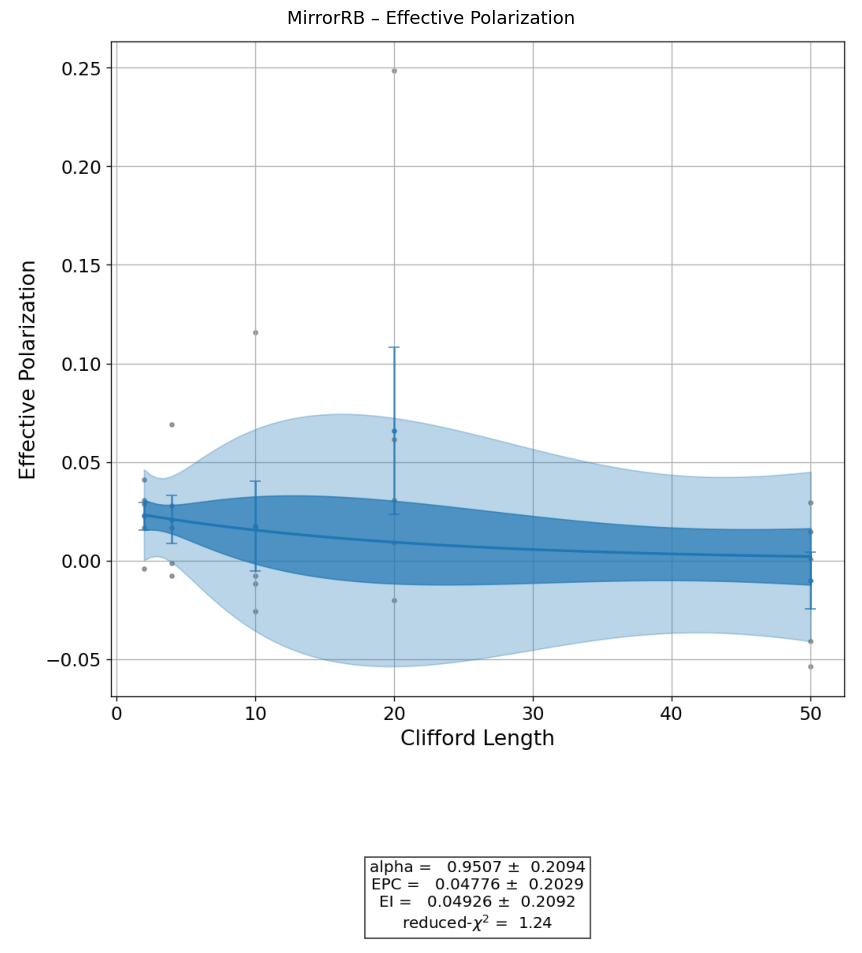

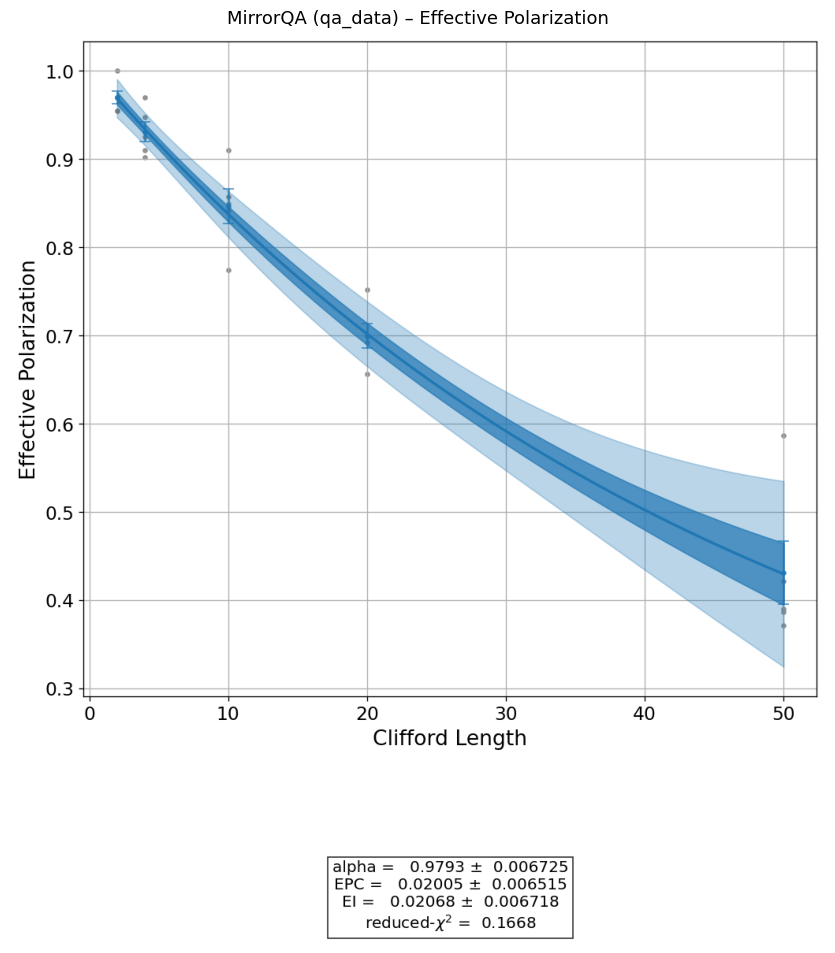

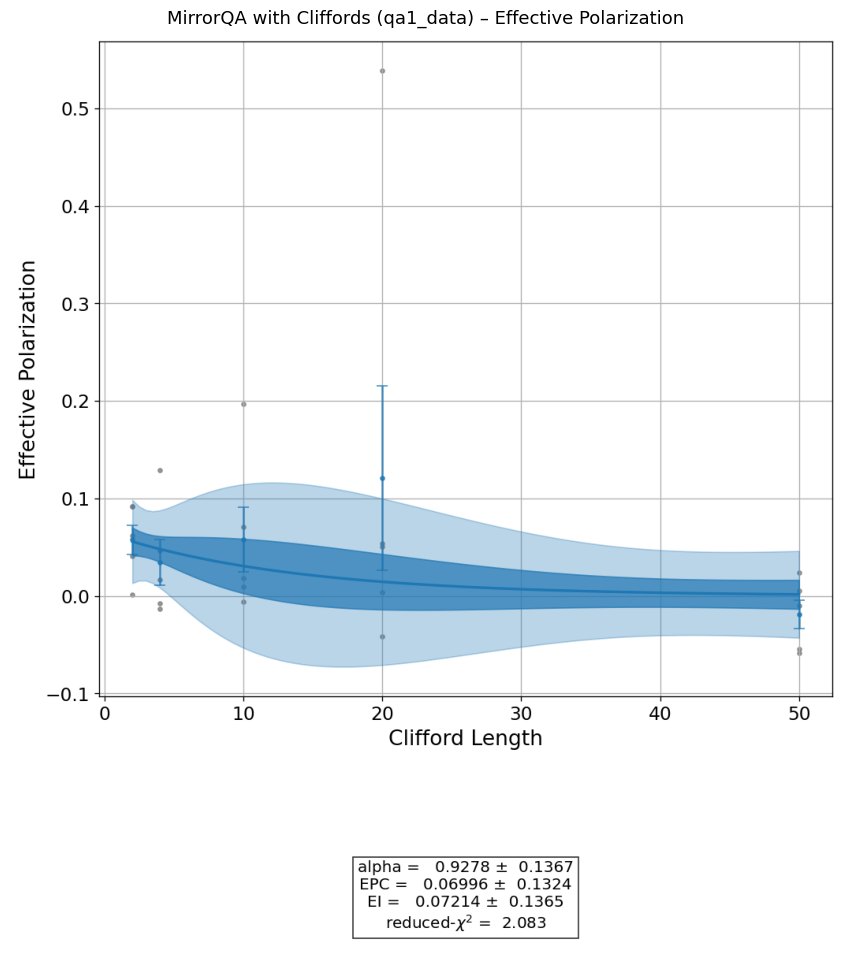

In [9]:
from IPython.display import display
import matplotlib.pyplot as plt, io
from matplotlib.backends.backend_agg import FigureCanvasAgg
import numpy as np

def _to_mpl(fig):
    for attr in ("figure", "_figure"):
        if hasattr(fig, attr):
            val = getattr(fig, attr)
            return val() if callable(val) else val
    return fig

def _full_rgba(mpl_fig, width_in=10, height_in=9):
    """Capture the entire figure (including stats block) using tight bbox."""
    mpl_fig.set_size_inches(width_in, height_in)
    buf = io.BytesIO()
    mpl_fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    buf.seek(0)
    return plt.imread(buf)

panels = [
    (analysis.figure(0),  "MirrorRB – Effective Polarization"),
    (analysis1.figure(0), "MirrorQA (qa_data) – Effective Polarization"),
    (analysis2.figure(0), "MirrorQA with Cliffords (qa1_data) – Effective Polarization"),
]

for qe_fig, title in panels:
    arr = _full_rgba(_to_mpl(qe_fig))
    fig, ax = plt.subplots(figsize=(10, arr.shape[0] / 120))
    ax.imshow(arr)
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=6)
    plt.tight_layout()
    display(fig)
    plt.close(fig)


In this step, I cross-check that when mrb data is processed using the mqa data processor, it produces the same graph as mqa with Cliffords enabled, confirming consistency between the two.

In [10]:
from qiskit_device_benchmarking.bench_code.mrb.mirror_rb_analysis import MirrorRBAnalysis
from qiskit_device_benchmarking.bench_code.mrb.mirror_qa import MirrorQAAnalysis

rb_an = MirrorRBAnalysis(); rb_an.set_options(analyzed_quantity="Effective Polarization")
qa_an = MirrorQAAnalysis(); qa_an.set_options(analyzed_quantity="Effective Polarization")

# Run RB analysis and SAVE outputs immediately
rb_exp = rb_an.run(rb_data, replace_results=True).block_for_results()
rb_figs = list(rb_exp.figure_names)
rb_df = rb_exp.analysis_results(dataframe=True).copy()

# Run QA analysis and SAVE outputs immediately
qa_exp = qa_an.run(rb_data, replace_results=True).block_for_results()
qa_figs = list(qa_exp.figure_names)
qa_df = qa_exp.analysis_results(dataframe=True).copy()

print("RB figs:", rb_figs)
print("QA figs:", qa_figs)
print("\nRB alpha rows:\n", rb_df[rb_df["name"] == "alpha"][["name","value"]])
print("\nQA alpha rows:\n", qa_df[qa_df["name"] == "alpha"][["name","value"]])

RB figs: ['MirrorRB_Q0_Q1_Q2_Q3_Q4_2fb5c667.svg']
QA figs: ['MirrorRB_Q0_Q1_Q2_Q3_Q4_2fb5c667.svg']

RB alpha rows:
            name        value
9797a94c  alpha  0.95+/-0.21

QA alpha rows:
            name        value
b80491af  alpha  0.93+/-0.14


MRB data + MQA processor alpha:
           name        value
2aa4969f  alpha  0.93+/-0.14


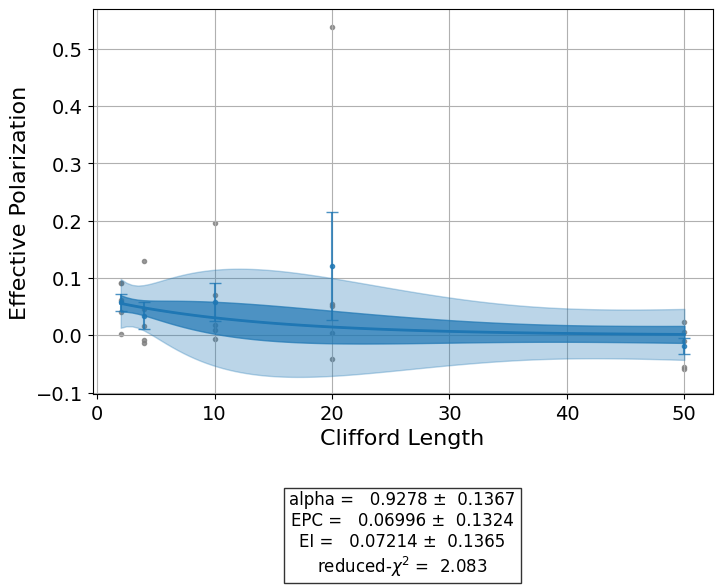

In [11]:
from qiskit_device_benchmarking.bench_code.mrb.mirror_qa import MirrorQAAnalysis

# 1) Apply MQA compute-quantities path on MRB dataset
qa_on_mrb = MirrorQAAnalysis()
qa_on_mrb.set_options(analyzed_quantity="Effective Polarization")
mrb_with_qa_proc = qa_on_mrb.run(rb_data, replace_results=True).block_for_results()  # rb_data = your MRB ExperimentData

print("MRB data + MQA processor alpha:")
print(mrb_with_qa_proc.analysis_results(dataframe=True).query("name == 'alpha'")[["name", "value"]])
display(mrb_with_qa_proc.figure(0))

In [12]:
# Deterministic reproducibility check (compare counts only)
# that can fail with custom Target ('HighLevelSynthesis ... measure').

backend.set_options(seed_simulator=123, max_parallel_threads=1, max_parallel_experiments=1)
exp.set_run_options(shots=shots, seed_simulator=123)

run1 = exp.run()
run1.block_for_results()
run2 = exp.run()
run2.block_for_results()

def extract_counts(expdata):
    out = []
    for entry in expdata.data():
        c = entry.get("counts", {})
        # canonicalize order for robust comparison/printing
        out.append(dict(sorted(c.items())))
    return out

counts1 = extract_counts(run1)
counts2 = extract_counts(run2)

print("same number of circuits:", len(counts1) == len(counts2), len(counts1), len(counts2))
print("counts identical:", counts1 == counts2)

if counts1 != counts2:
    mismatches = [i for i, (a, b) in enumerate(zip(counts1, counts2)) if a != b]
    print("mismatch count:", len(mismatches))
    i = mismatches[0]
    print("first mismatch index:", i)
    print("run1 counts:", counts1[i])
    print("run2 counts:", counts2[i])

# NOTE:
# run1.data() == run2.data() can be False even when counts are identical,
# because metadata (job IDs, timestamps, callback info) differs run-to-run.


same number of circuits: True 25 25
counts identical: True
